In [27]:
!pip install pandas numpy matplotlib seaborn

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from google.colab import files
uploaded = files.upload()

Saving student_dropout_dataset.csv to student_dropout_dataset (1).csv


In [30]:
df = pd.read_csv("student_dropout_dataset.csv")
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [31]:
df.shape

(5000, 15)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [33]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000


In [34]:
df.isnull().sum()

,0
student_id,0
age,0
region,0
enroll_date,0
exam_season,0
courses_enrolled,0
completed_assignments,0
completion_rate,0
login_frequency,0
last_activity_days_ago,0


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df['enroll_date'] = pd.to_datetime(df['enroll_date'])

In [37]:
df['enroll_date']

,enroll_date
0,2024-01-13
1,2024-05-05
2,2024-03-12
3,2024-12-12
4,2024-02-14
...,...
4995,2024-07-10
4996,2024-09-22
4997,2024-04-01
4998,2024-12-30


In [38]:
df['region'] = df['region'].str.strip()

In [39]:
df['region']

,region
0,Alexandria
1,Amman
2,Dubai
3,Alexandria
4,Baghdad
...,...
4995,Baghdad
4996,Casablanca
4997,Casablanca
4998,Beirut


In [40]:
df['engagement_score'] = (
    df['login_frequency'] +
    df['completed_assignments'] -
    df['last_activity_days_ago'] / 10
)

In [41]:
df['engagement_score']

,engagement_score
0,9.29
1,0.14
2,-0.81
3,12.88
4,4.82
...,...
4995,17.96
4996,6.66
4997,7.55
4998,4.94


In [42]:
def activity_level(row):
    if row['login_frequency'] > 7 and row['completion_rate'] > 0.7:
        return "High"
    elif row['login_frequency'] > 3:
        return "Medium"
    else:
        return "Low"

df['activity_level'] = df.apply(activity_level, axis=1)

In [43]:
df['activity_level']

,activity_level
0,Medium
1,Low
2,Low
3,Low
4,Low
...,...
4995,Medium
4996,Medium
4997,Medium
4998,Medium


In [44]:
def risk_level(row):
    if row['completion_rate'] < 0.3 and row['login_frequency'] < 3:
        return "High Risk"
    elif row['completion_rate'] < 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_level'] = df.apply(risk_level, axis=1)

In [45]:
df['risk_level']

,risk_level
0,Medium Risk
1,High Risk
2,High Risk
3,Medium Risk
4,High Risk
...,...
4995,Low Risk
4996,Medium Risk
4997,Medium Risk
4998,Medium Risk


In [46]:
df['label'].value_counts()

,count
label,
1,3296
0,1704


In [47]:
df['region'].value_counts()

,count
region,
Doha,534
Baghdad,532
Riyadh,510
Casablanca,509
Tunis,499
Alexandria,493
Cairo,484
Dubai,482
Amman,481


In [48]:
df['engagement_score'].mean()

np.float64(7.706579999999999)

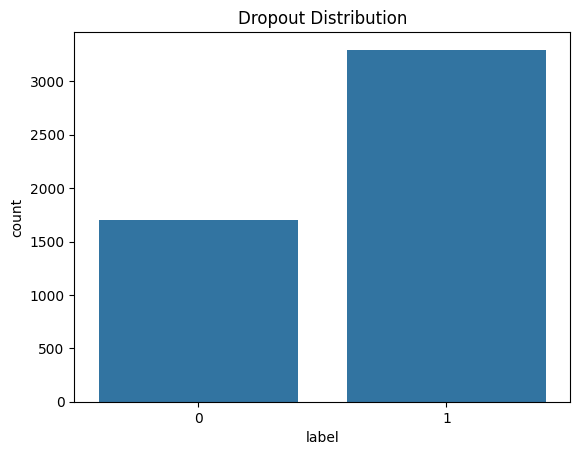

In [49]:
sns.countplot(x='label', data=df)
plt.title("Dropout Distribution")
plt.show()

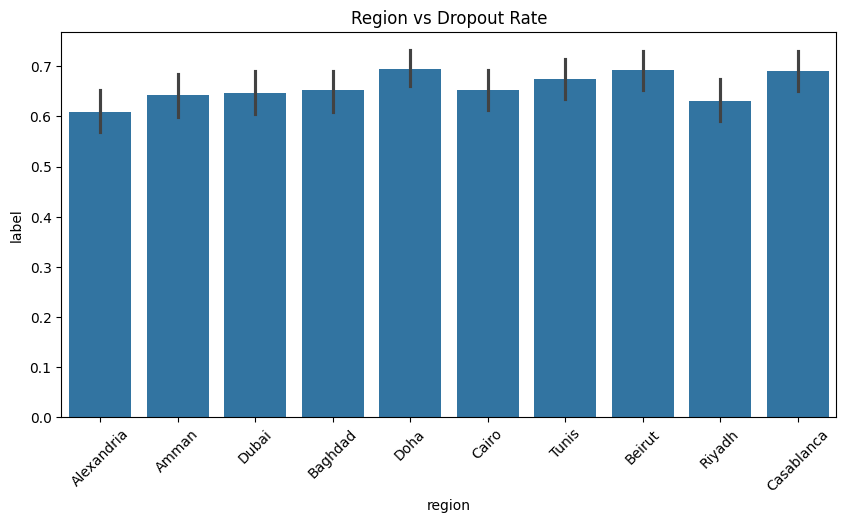

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(x='region', y='label', data=df)
plt.xticks(rotation=45)
plt.title("Region vs Dropout Rate")
plt.show()

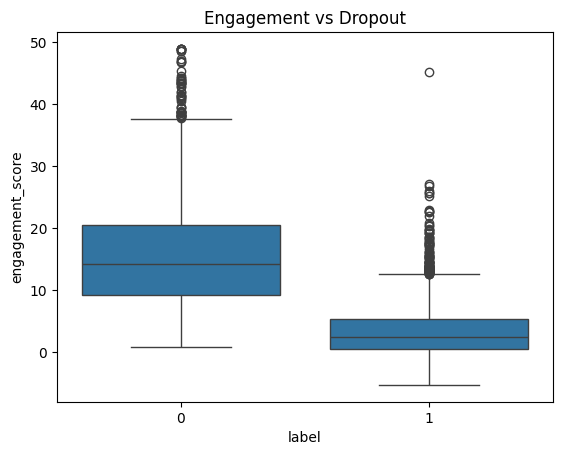

In [51]:
sns.boxplot(x='label', y='engagement_score', data=df)
plt.title("Engagement vs Dropout")
plt.show()

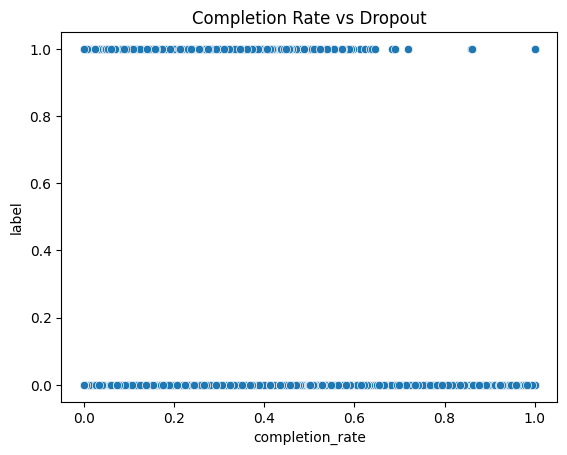

In [52]:
sns.scatterplot(x='completion_rate', y='label', data=df)
plt.title("Completion Rate vs Dropout")
plt.show()

In [53]:
df.to_csv("clean_student_dropout.csv", index=False)